In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('insurance_data.csv')
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


In [4]:
X = df[['age']]
y = df['bought_insurance']
X.shape

(27, 1)

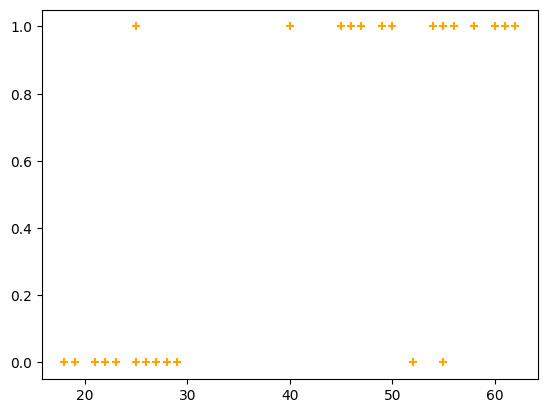

In [9]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='orange')

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.8)

In [12]:
X_test

,age
16,25
0,22
18,19
3,52
10,18
2,47


In [13]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [14]:
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
X_test

,age
16,25
0,22
18,19
3,52
10,18
2,47


In [16]:
y_predicted = model.predict(X_test)

In [17]:
model.predict_proba(X_test)

array([[0.94865512, 0.05134488],
       [0.97107338, 0.02892662],
       [0.98386978, 0.01613022],
       [0.0788587 , 0.9211413 ],
       [0.98674259, 0.01325741],
       [0.18805625, 0.81194375]])

In [18]:
model.score(X_test,y_test)

0.6666666666666666

In [19]:
y_predicted

array([0, 0, 0, 1, 0, 1])

In [20]:
X_test

,age
16,25
0,22
18,19
3,52
10,18
2,47


In [21]:
model.coef_

array([[0.19905318]])

In [22]:
model.intercept_

array([-7.89280969])

In [23]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [24]:
def prediction_function(age):
    z = 0.042 * age - 1.53 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z)
    return y

In [25]:
age = 35
prediction_function(age)

0.4850044983805899

In [26]:
age = 43
prediction_function(age)

0.568565299077705

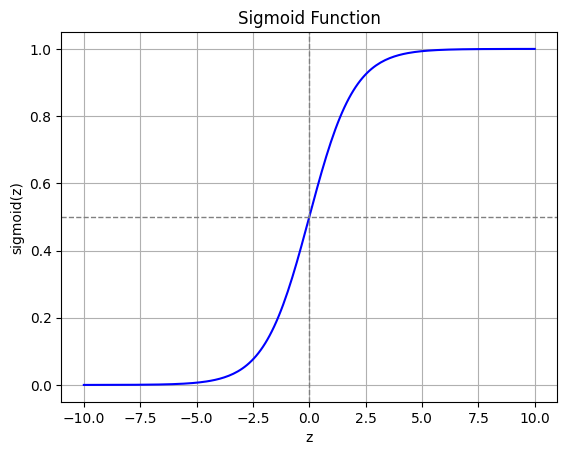

In [27]:
import numpy as np

x = np.linspace(-10, 10, 200)
y = 1 / (1 + np.exp(-x))

plt.plot(x, y, color='blue')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


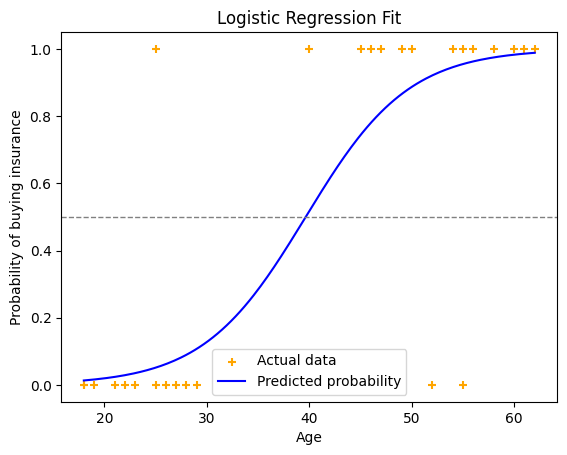

In [29]:
ages = np.linspace(df.age.min(), df.age.max(), 200).reshape(-1, 1)
probabilities = model.predict_proba(ages)[:, 1]

plt.scatter(df.age, df.bought_insurance, marker='+', color='orange', label='Actual data')
plt.plot(ages, probabilities, color='blue', label='Predicted probability')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Age')
plt.ylabel('Probability of buying insurance')
plt.title('Logistic Regression Fit')
plt.legend()
plt.show()

In [30]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_predicted)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_predicted))

Confusion Matrix:
 [[3 1]
 [1 1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



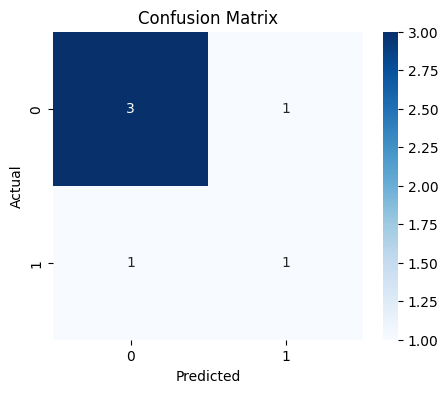

In [31]:
import seaborn as sn

plt.figure(figsize=(5,4))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()